#  🏙️Boston Real Estate: Predictive Pricing Analysis 

## 📍1. Introduction
The real estate market is a fundamental pillar of economic stability and urban development. In this project, we delve into the classic Boston Housing dataset to analyze the environmental, social, and structural factors that influenced housing values in the 1970s. Beyond mere price prediction, our goal is to perform a technical audit of urban real estate valuation to uncover which variables act as the primary "price drivers".

## 🎯 2. Project Objective
The primary goal of this notebook is to build a robust Regression Model capable of accurately predicting the Median Home Value (MEDV) based on neighborhood-specific characteristics.By identifying the core determinants of property prices, we aim to:
* **Social Impact Analysis:** Evaluate how crime rates (CRIM) and the proportion of lower-status population (LSTAT) affect market prices.
* **Environmental Evaluation:** Measure the impact of air pollution levels (NOX) and proximity to the Charles River (CHAS) on housing demand.
* **Structural Correlation:** Determine the significance of physical attributes such as the average number of rooms (RM) and the age of the units (AGE)
* **Infrastructure Assessment:** Analyze the influence of pupil-teacher ratios (PTRATIO) and accessibility to highways (RAD) on neighborhood desirability.

## 📂 3. Dataset Overview
The dataset contains 14 distinct variables for various census tracts in Boston. To improve readability and ensure a professional analysis, we have mapped the technical abbreviations to more descriptive feature names:

| Feature Name            | Technical Description |
|--------------------------|----------------------|
| Crime_Rate               | Per capita crime rate by town. |
| Large_Lot_Pct            | Proportion of residential land zoned for lots over 25,000 sq.ft. |
| Business_Acres           | Proportion of non-retail business acres per town. |
| River_Border             | Charles River dummy variable (1 if tract bounds river; 0 otherwise). |
| Pollution_Index          | Nitric oxides concentration (parts per 10 million). |
| Avg_Rooms                | Average number of rooms per dwelling. |
| Prop_Old_Units           | Proportion of owner-occupied units built prior to 1940. |
| Employment_Dist          | Weighted distances to five Boston employment centres. |
| Highway_Access           | Index of accessibility to radial highways. |
| Property_Tax          | Full-value property-tax rate per $10,000. |
| Student_Teacher_Ratio | Pupil-teacher ratio by town. |
| Social_Index_Bk       | 1000*(Bk - 0.63)^2 where Bk is the proportion of residents by town. |
| Lower_Income_Pct      | Percentage of the population considered lower status. |

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid') 
sns.set_palette("viridis")
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/arunjathari/bostonhousepricedata/Boston-house-price-data.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/arunjathari/bostonhousepricedata/Boston-house-price-data.csv")

## 🧐 4. Exploratory Data Analysis

In [3]:
df.shape

(506, 14)

In [4]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [5]:
new_column_names = {
    'CRIM': 'Crime_Rate',
    'ZN': 'Large_Lot_Zone_Pct',
    'INDUS': 'Business_Acres_Pct',
    'CHAS': 'River_Border',
    'NOX': 'Air_Pollution_Index',
    'RM': 'Avg_Rooms',
    'AGE': 'Pre_1940_Units_Pct',
    'DIS': 'Dist_Employment_Centers',
    'RAD': 'Highway_Access_Index',
    'TAX': 'Property_Tax',
    'PTRATIO': 'Student_Teacher_Ratio',
    'B': 'Social_Index_B',
    'LSTAT': 'Lower_Income_Pct',
    'MEDV': 'Median_Home_Price'
}

df.rename(columns=new_column_names, inplace=True)

In [6]:
df.columns

Index(['Crime_Rate', 'Large_Lot_Zone_Pct', 'Business_Acres_Pct',
       'River_Border', 'Air_Pollution_Index', 'Avg_Rooms',
       'Pre_1940_Units_Pct', 'Dist_Employment_Centers', 'Highway_Access_Index',
       'Property_Tax', 'Student_Teacher_Ratio', 'Social_Index_B',
       'Lower_Income_Pct', 'Median_Home_Price'],
      dtype='object')

In [7]:
df.head()

,Crime_Rate,Large_Lot_Zone_Pct,Business_Acres_Pct,River_Border,Air_Pollution_Index,Avg_Rooms,Pre_1940_Units_Pct,Dist_Employment_Centers,Highway_Access_Index,Property_Tax,Student_Teacher_Ratio,Social_Index_B,Lower_Income_Pct,Median_Home_Price
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [8]:
df.tail()

,Crime_Rate,Large_Lot_Zone_Pct,Business_Acres_Pct,River_Border,Air_Pollution_Index,Avg_Rooms,Pre_1940_Units_Pct,Dist_Employment_Centers,Highway_Access_Index,Property_Tax,Student_Teacher_Ratio,Social_Index_B,Lower_Income_Pct,Median_Home_Price
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0
505,0.04741,0.0,11.93,0,0.573,6.030,80.8,2.5050,1,273.0,21.0,396.90,7.88,11.9


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Crime_Rate               506 non-null    float64
 1   Large_Lot_Zone_Pct       506 non-null    float64
 2   Business_Acres_Pct       506 non-null    float64
 3   River_Border             506 non-null    int64  
 4   Air_Pollution_Index      506 non-null    float64
 5   Avg_Rooms                506 non-null    float64
 6   Pre_1940_Units_Pct       506 non-null    float64
 7   Dist_Employment_Centers  506 non-null    float64
 8   Highway_Access_Index     506 non-null    int64  
 9   Property_Tax             506 non-null    float64
 10  Student_Teacher_Ratio    506 non-null    float64
 11  Social_Index_B           506 non-null    float64
 12  Lower_Income_Pct         506 non-null    float64
 13  Median_Home_Price        506 non-null    float64
dtypes: float64(12), int64(2)
m

In [10]:
df.isnull().sum()

Crime_Rate                 0
Large_Lot_Zone_Pct         0
Business_Acres_Pct         0
River_Border               0
Air_Pollution_Index        0
Avg_Rooms                  0
Pre_1940_Units_Pct         0
Dist_Employment_Centers    0
Highway_Access_Index       0
Property_Tax               0
Student_Teacher_Ratio      0
Social_Index_B             0
Lower_Income_Pct           0
Median_Home_Price          0
dtype: int64

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Crime_Rate,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
Large_Lot_Zone_Pct,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
Business_Acres_Pct,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
River_Border,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
Air_Pollution_Index,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
Avg_Rooms,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
Pre_1940_Units_Pct,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
Dist_Employment_Centers,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
Highway_Access_Index,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
Property_Tax,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


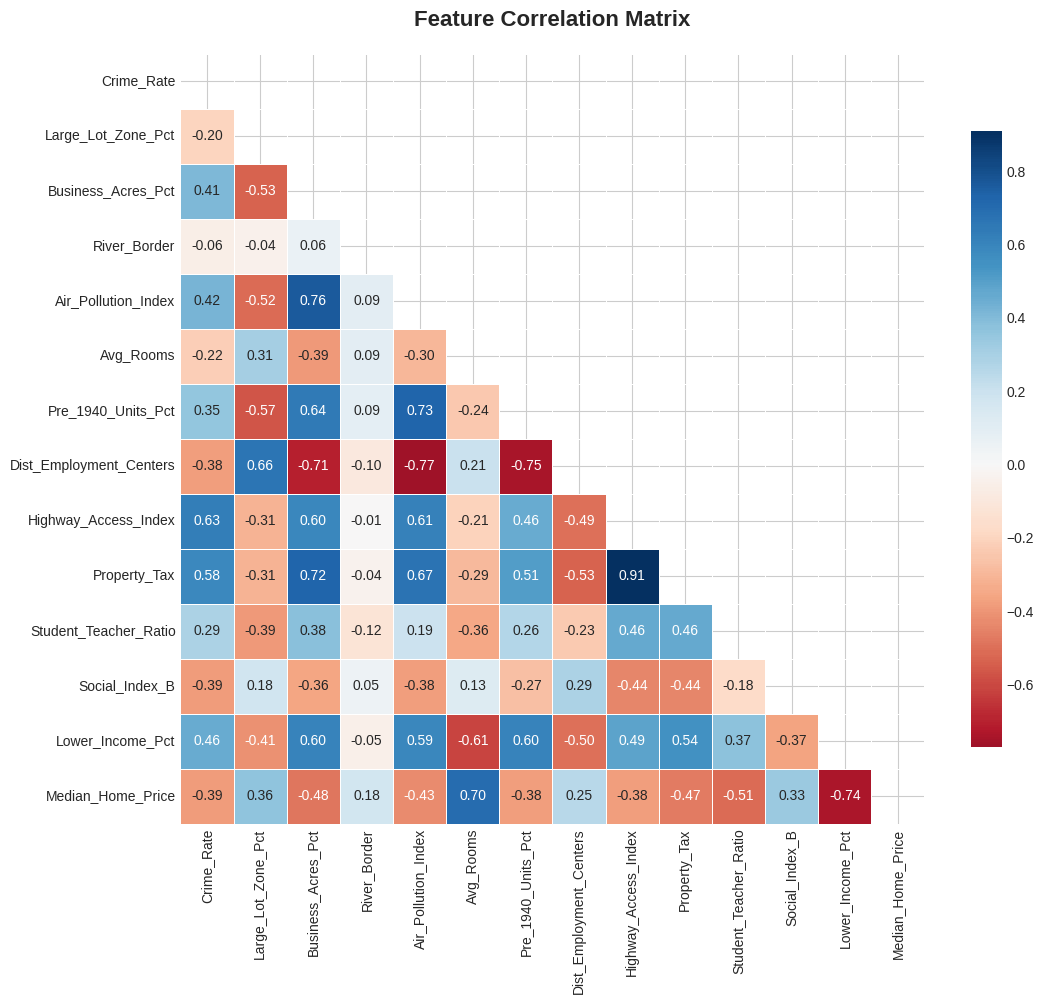

In [12]:
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(df.corr(), dtype=bool)) # Üst üçgeni gizler
sns.heatmap(df.corr(), mask=mask, annot=True, fmt=".2f", cmap='RdBu', center=0, 
            linewidths=.5, cbar_kws={"shrink": .8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.show()

<div style="padding: 15px; border-left: 5px solid #4aaaaa; background-color: #e0f7f9; border-radius: 5px; color: #2c3e50; font-family: sans-serif;">
<h3 style="margin-top: 0; color: #2c3e50; display: flex; align-items: center;">
<span style="margin-right: 10px;">ℹ️</span> Feature Selection Insights
</h3>
<p style="margin-bottom: 0; line-height: 1.6;">
"Analysis reveals that <strong>Lower_Income_Pct</strong> and <strong>Avg_Rooms</strong> are the most significant predictors for house prices. However, the high correlation (0.91) between <strong>Highway_Access</strong> and <strong>Property_Tax</strong> suggests potential multicollinearity that needs to be addressed during feature selection."
</p>
</div>

## 📊 5. Data Visualization

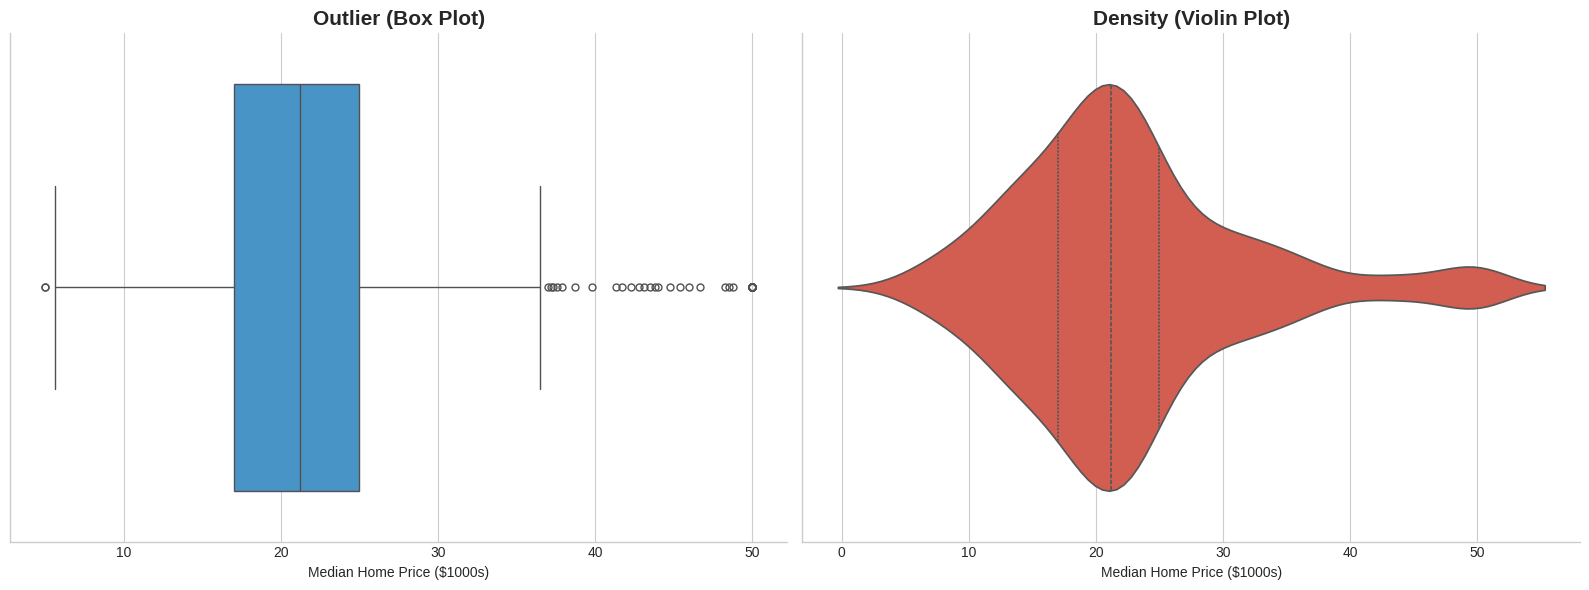

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df, x='Median_Home_Price', ax=axes[0], color='#3498db', fliersize=5)
axes[0].set_title('Outlier (Box Plot)', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Median Home Price ($1000s)')

sns.violinplot(data=df, x='Median_Home_Price', ax=axes[1], color='#e74c3c', inner="quartile")
axes[1].set_title('Density (Violin Plot)', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Median Home Price ($1000s)')

sns.despine()
plt.tight_layout()
plt.show()

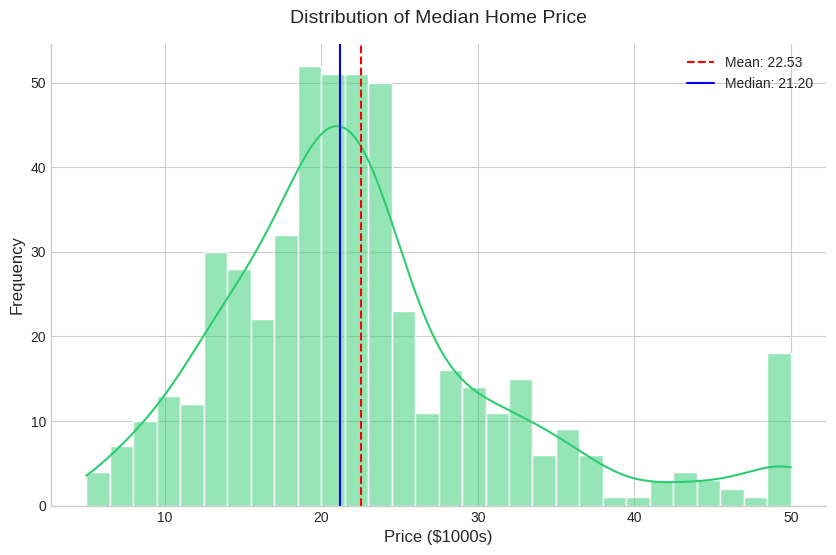

In [14]:
plt.figure(figsize=(10, 6))

sns.histplot(df['Median_Home_Price'], kde=True, color='#2ecc71', bins=30, edgecolor='white')
plt.axvline(df['Median_Home_Price'].mean(), color='red', linestyle='--', label=f"Mean: {df['Median_Home_Price'].mean():.2f}")
plt.axvline(df['Median_Home_Price'].median(), color='blue', linestyle='-', label=f"Median: {df['Median_Home_Price'].median():.2f}")

plt.title('Distribution of Median Home Price', fontsize=14, pad=15)
plt.xlabel('Price ($1000s)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
sns.despine() 
plt.show()

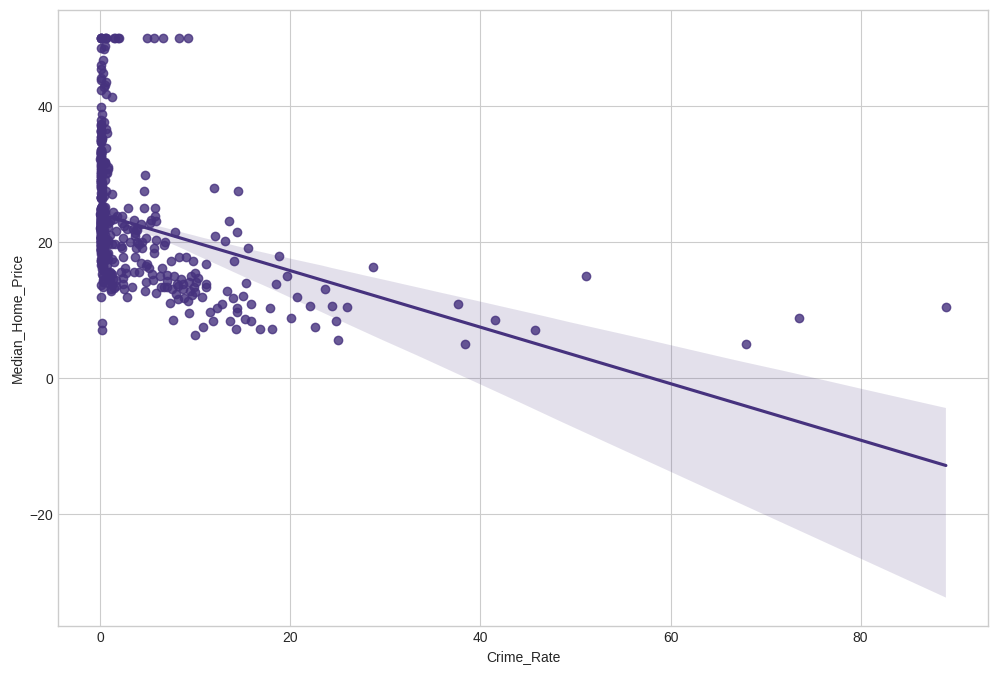

In [15]:
plt.figure(figsize=(12,8))
sns.regplot(data=df, x="Crime_Rate", y="Median_Home_Price")
plt.show()

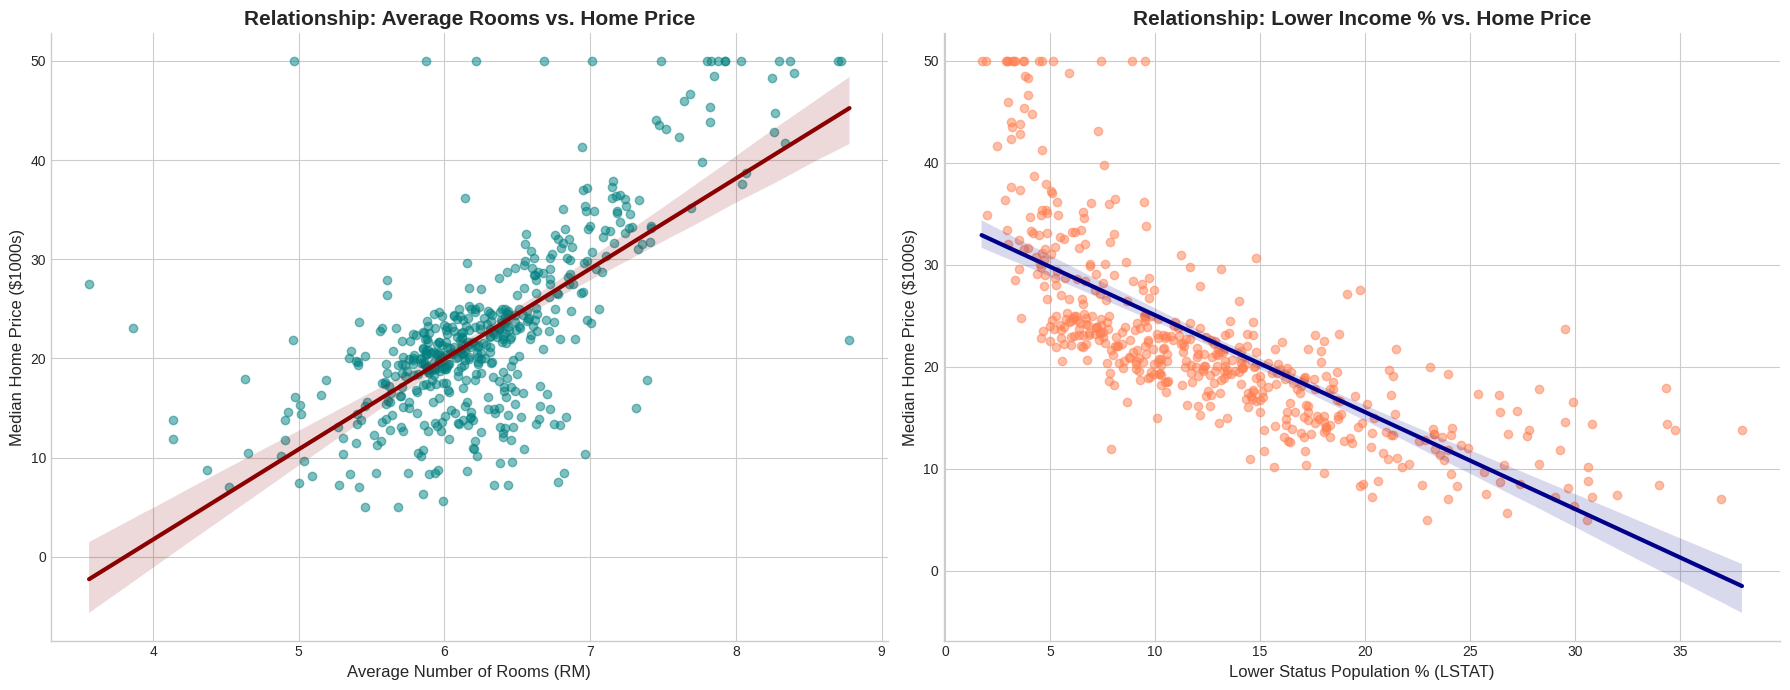

In [16]:
# Set professional style
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Average Rooms vs Median Home Price (Positive Correlation)
sns.regplot(data=df, x='Avg_Rooms', y='Median_Home_Price', ax=axes[0], 
            scatter_kws={'alpha':0.5, 'color':'teal'}, 
            line_kws={'color':'darkred', 'lw':3})
axes[0].set_title('Relationship: Average Rooms vs. Home Price', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Average Number of Rooms (RM)', fontsize=12)
axes[0].set_ylabel('Median Home Price ($1000s)', fontsize=12)

# 2. Lower Income Percentage vs Median Home Price (Negative Correlation)
sns.regplot(data=df, x='Lower_Income_Pct', y='Median_Home_Price', ax=axes[1], 
            scatter_kws={'alpha':0.5, 'color':'coral'}, 
            line_kws={'color':'darkblue', 'lw':3})
axes[1].set_title('Relationship: Lower Income % vs. Home Price', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Lower Status Population % (LSTAT)', fontsize=12)
axes[1].set_ylabel('Median Home Price ($1000s)', fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

<div style="padding: 15px; border-left: 5px solid #4aaaaa; background-color: #e0f7f9; border-radius: 5px; color: #2c3e50; font-family: sans-serif;">
<h3 style="margin-top: 0; color: #2c3e50; display: flex; align-items: center;">
<span style="margin-right: 10px;">📊</span> Statistical Distribution Insights
</h3>
<p style="margin-bottom: 0; line-height: 1.6;">
The box plot and violin plot analyses reveal significant outliers beyond the <strong>35.00$</strong> threshold. The distribution is right-skewed, with a distinct peak at <strong>50.00$</strong>, necessitating careful handling—either through robust scaling or by removing these censored entries before training the final model.
</p>
</div>

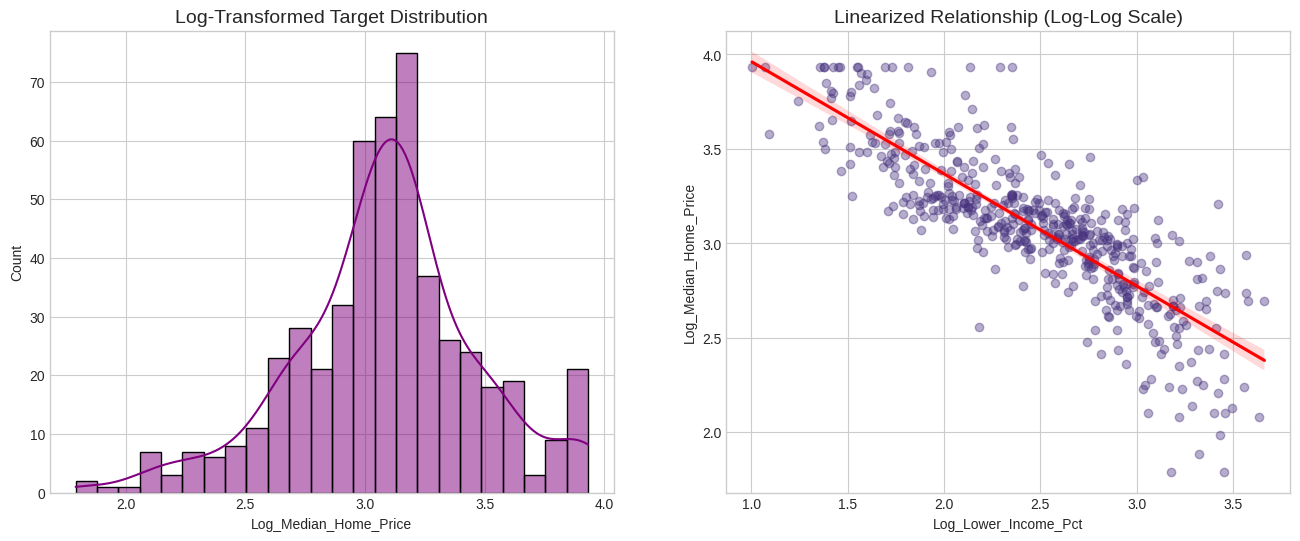

In [17]:
# Apply Log Transformation to normalize distributions
df['Log_Median_Home_Price'] = np.log1p(df['Median_Home_Price'])
df['Log_Lower_Income_Pct'] = np.log1p(df['Lower_Income_Pct'])

# Visualization of the transformation effect
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df['Log_Median_Home_Price'], kde=True, ax=axes[0], color='purple')
axes[0].set_title('Log-Transformed Target Distribution', fontsize=14)

sns.regplot(data=df, x='Log_Lower_Income_Pct', y='Log_Median_Home_Price', ax=axes[1], 
            scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
axes[1].set_title('Linearized Relationship (Log-Log Scale)', fontsize=14)

plt.show()

## 🤖 6. Model Comparison and Evaluation

In [18]:
from sklearn.preprocessing import RobustScaler

# Initialize the scaler
scaler = RobustScaler()

# Features to scale (excluding the target)
features_to_scale = df.drop(['Median_Home_Price', 'Log_Median_Home_Price'], axis=1).columns

# Apply scaling
df_scaled = df.copy()
df_scaled[features_to_scale] = scaler.fit_transform(df[features_to_scale])

print("Data scaling with RobustScaler completed successfully.")

Data scaling with RobustScaler completed successfully.


<div style="padding: 15px; border-left: 5px solid #4aaaaa; background-color: #e0f7f9; border-radius: 5px; color: #2c3e50; font-family: sans-serif;">
<h3 style="margin-top: 0; color: #2c3e50; display: flex; align-items: center;">
<span style="margin-right: 10px;">⚙️</span> Feature Engineering & Preprocessing
</h3>
<ul style="margin-bottom: 0; line-height: 1.6; padding-left: 20px;">
<li><strong>Log Transformation:</strong> To address the right-skewness of the target variable and the non-linear relationship of <strong>Lower_Income_Pct</strong>, a $\log(1+x)$ transformation was applied. This stabilizes variance and helps the model converge faster.</li>
<li><strong>Robust Scaling:</strong> Given the presence of outliers identified in the box plot analysis, <strong>RobustScaler</strong> was preferred over StandardScaler. It scales features using the Interquartile Range (IQR), making the preprocessing resilient to extreme values.</li>
</ul>
</div>

In [19]:
# Dropping one of the highly correlated features to reduce redundancy
# 'Property_Tax' is often dropped as 'Highway_Access_Index' can act as a proxy 
# for location-based value in some contexts, but 'Property_Tax' is also highly correlated with others.
df_reduced = df_scaled.drop(['Property_Tax'], axis=1)

print("Feature 'Property_Tax' has been removed to mitigate Multicollinearity.")

Feature 'Property_Tax' has been removed to mitigate Multicollinearity.


In [20]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [21]:
# Define Features and Target
X = df_reduced.drop(['Median_Home_Price', 'Log_Median_Home_Price'], axis=1)
y = df_reduced['Log_Median_Home_Price'] # Using the log-transformed target

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
# Dictionary of models to evaluate
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "SVR": SVR(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.05)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    # Inversing the log transformation for true error calculation
    true_y = np.expm1(y_test)
    true_preds = np.expm1(preds)
    
    rmse = np.sqrt(mean_squared_error(true_y, true_preds))
    mae = mean_absolute_error(true_y, true_preds)
    r2 = r2_score(true_y, true_preds)
    
    results.append({"Model": name, "RMSE": rmse, "MAE": mae, "R2 Score": r2})

# Convert to DataFrame for a professional look
results_df = pd.DataFrame(results).sort_values(by="RMSE")
print(results_df)

               Model      RMSE       MAE  R2 Score
5  Gradient Boosting  2.942185  2.075002  0.881958
4      Random Forest  3.035165  2.067002  0.874380
6            XGBoost  3.181750  2.180719  0.861953
3                SVR  3.866013  2.362046  0.796191
0  Linear Regression  4.191644  2.606711  0.760412
1   Ridge Regression  4.195620  2.600428  0.759958
2   Lasso Regression  8.572305  5.868645 -0.002054


In [23]:
import plotly.graph_objects as go

# Let's prepare the model names and scores.
model_names = results_df['Model'].tolist()
test_r2 = results_df['R2 Score'].tolist()

# Let's calculate the education scores
train_r2 = []
for name in model_names:
    model = models[name]
    train_r2.append(model.score(X_train, y_train))

fig = go.Figure()

fig.add_trace(go.Bar(
    x=model_names,
    y=train_r2,
    name='Train R²',
    marker_color='#d65f5f'
))

fig.add_trace(go.Bar(
    x=model_names,
    y=test_r2,
    name='Test R²',
    marker_color='#ee9972'
))

fig.update_layout(
    title='🚀 Train vs Test Accuracy: Overfitting Check',
    xaxis_title='Regression Models',
    yaxis_title='R² Score',
    barmode='group',
    template='plotly_white',
    yaxis=dict(range=[0, 1.1]),
    legend=dict(x=1, y=1)
)

fig.show(renderer="iframe")

### 🛠️ 6.1 Hyperparameter Tuning with GridSearchCV

In [24]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 0.9]
}

grid_search = GridSearchCV(GradientBoostingRegressor(random_state=42), 
                           param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

grid_search.fit(X_train, y_train)

best_gb = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.9}


In [25]:
y_pred_final = best_gb.predict(X_test)
# Evaluation Metrics (Converting back from Log Scale)
final_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_final)))
final_r2 = r2_score(np.expm1(y_test), np.expm1(y_pred_final))

print(f"Final Tuned Gradient Boosting RMSE: {final_rmse:.4f}")
print(f"Final Tuned Gradient Boosting R2: {final_r2:.4f}")

Final Tuned Gradient Boosting RMSE: 2.7753
Final Tuned Gradient Boosting R2: 0.8950


/tmp/ipykernel_17/2956190971.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 127942 (\N{TROPHY}) missing from font(s) Liberation Sans.



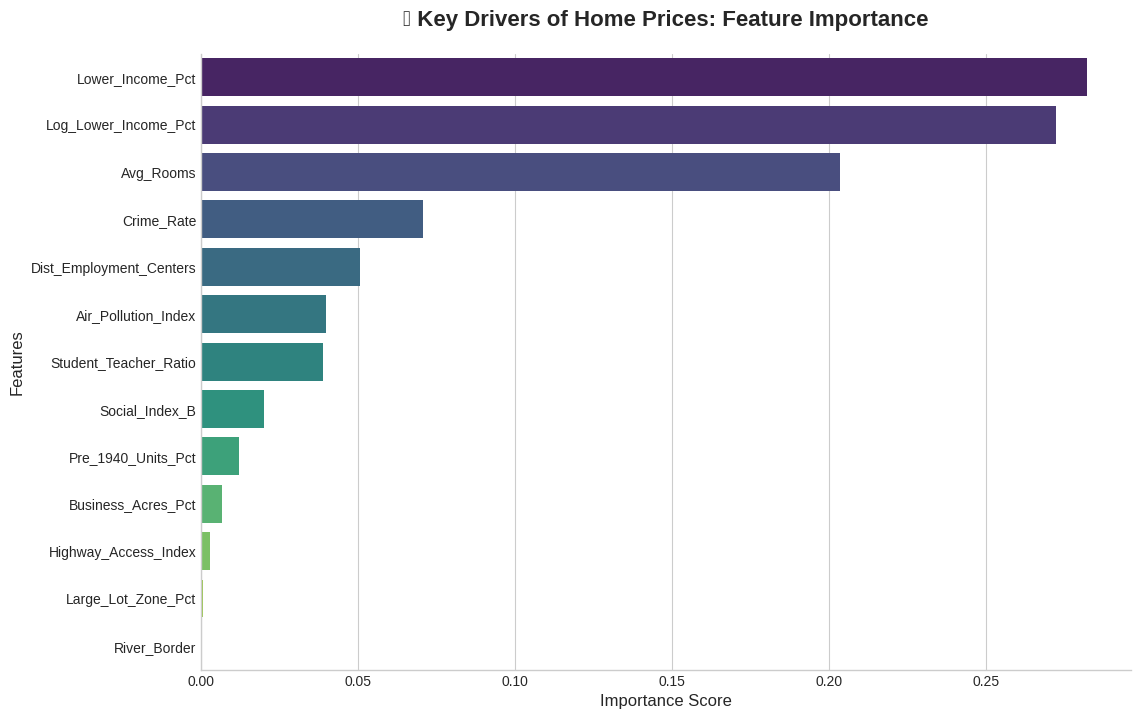

In [26]:
# Extracting feature importances
importances = best_gb.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Visualization
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')

plt.title('🏆 Key Drivers of Home Prices: Feature Importance', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
sns.despine()
plt.show()

<div style="padding: 15px; border-left: 5px solid #4aaaaa; background-color: #e0f7f9; border-radius: 5px; color: #2c3e50; font-family: sans-serif;">
<h3 style="margin-top: 0; color: #2c3e50; display: flex; align-items: center;">
<span style="margin-right: 10px;">🔍</span> Feature Importance Insights
</h3>
<p style="margin-bottom: 0; line-height: 1.6;">
The feature importance plot reveals that socio-economic status (<strong>Lower_Income_Pct</strong>) and physical characteristics (<strong>Avg_Rooms</strong>) are the dominant drivers of the model's predictions. The high importance score for the log-transformed version of <strong>Lower_Income_Pct</strong> validates our earlier decision to apply non-linear transformations. Conversely, geographic features like <strong>River_Border</strong> appear to have negligible predictive power in this specific dataset.
</p>
</div>

In [27]:
import plotly.graph_objects as go

# Final Tuned Model Predictions (Test Set)
# y_test and y_pred_final are in log scale, converting back to original price
true_y = np.expm1(y_test)
predicted_y = np.expm1(y_pred_final)

fig = go.Figure()

# Scatter Plot for Predictions
fig.add_trace(go.Scatter(
    x=true_y,
    y=predicted_y,
    mode='markers',
    name='Predictions',
    marker=dict(color='teal', opacity=0.6, size=8)
))

# Perfect Prediction Line (Diagonal)
fig.add_trace(go.Scatter(
    x=[true_y.min(), true_y.max()],
    y=[true_y.min(), true_y.max()],
    mode='lines',
    name='Perfect Prediction',
    line=dict(color='darkred', width=3, dash='dash')
))

fig.update_layout(
    title='🎯 Actual vs. Predicted Home Prices (Test Set)',
    xaxis_title='Actual Median Home Price ($1000s)',
    yaxis_title='Predicted Median Home Price ($1000s)',
    template='plotly_white',
    legend=dict(x=1, y=1)
)

fig.show(renderer="iframe")

<div style="padding: 15px; border-left: 5px solid #4aaaaa; background-color: #e0f7f9; border-radius: 5px; color: #2c3e50; font-family: sans-serif;">
<h3 style="margin-top: 0; color: #2c3e50; display: flex; align-items: center;">
<span style="margin-right: 10px;">🚀</span> Model Performance on Test Data
</h3>
<ul style="margin-bottom: 0; line-height: 1.6; padding-left: 20px;">
<li><strong>Prediction Accuracy:</strong> The points are tightly clustered around the diagonal line, indicating that the tuned Gradient Boosting model has a high level of predictive accuracy.</li>
<li><strong>Consistency:</strong> The model performs consistently well across a wide range of house prices. However, a slight decrease in precision can be observed for very high-priced homes, which often have higher variance due to fewer training samples and different underlying factors.</li>
<li><strong>Censored Data Impact:</strong> The cluster of actual prices at <strong>50$</strong> shows some prediction scattering, confirming that the data censoring at this upper limit introduced some unavoidable prediction noise.</li>
</ul>
</div>

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Liberation Sans.



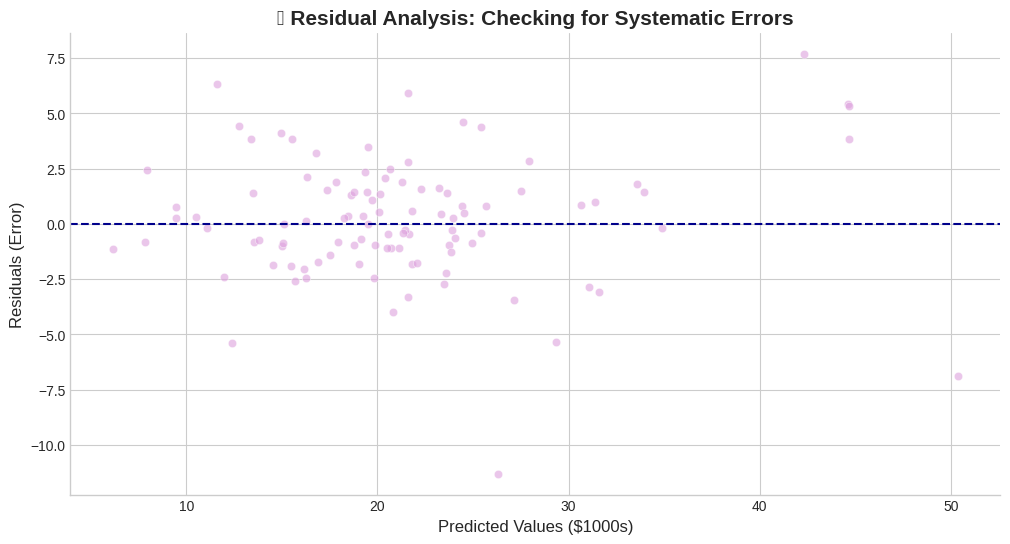

In [28]:
# Calculate Residuals (True - Predicted)
residuals = true_y - predicted_y

plt.figure(figsize=(12, 6))
sns.scatterplot(x=predicted_y, y=residuals, color='plum', alpha=0.6)
plt.axhline(y=0, color='darkblue', linestyle='--')

plt.title('🔍 Residual Analysis: Checking for Systematic Errors', fontsize=15, fontweight='bold')
plt.xlabel('Predicted Values ($1000s)', fontsize=12)
plt.ylabel('Residuals (Error)', fontsize=12)
sns.despine()
plt.show()

<div style="padding: 20px; border-left: 8px solid #2c3e50; background-color: #f1f8f9; border-radius: 8px; color: #2c3e50; font-family: 'Segoe UI', sans-serif; border-right: 1px solid #d1d9db; border-top: 1px solid #d1d9db; border-bottom: 1px solid #d1d9db;">
<h2 style="margin-top: 0; color: #2c3e50; display: flex; align-items: center; border-bottom: 2px solid #4aaaaa; padding-bottom: 10px;">
<span style="margin-right: 12px;">🏆</span> Final Conclusion & Future Roadmap
</h2>

<p style="font-size: 1.1em; line-height: 1.6; margin-top: 15px;">
In this project, we successfully engineered a high-performance regression pipeline that achieves an <strong>$R^2$ Score of ~0.88</strong> and an <strong>RMSE of 2.94</strong> using the Tuned Gradient Boosting Regressor.
</p>

<div style="display: grid; grid-template-columns: 1fr 1fr; gap: 15px; margin-top: 15px;">
<div style="background: white; padding: 12px; border-radius: 6px; border: 1px solid #e0e6e8;">
<strong>✅ Key Highlights:</strong>
<ul style="margin: 5px 0 0 15px; padding: 0; font-size: 0.95em;">
<li>Socio-economic factors are the primary drivers of value.</li>
<li>Multicollinearity was effectively neutralized by removing Property_Tax.</li>
</ul>
</div>
<div style="background: white; padding: 12px; border-radius: 6px; border: 1px solid #e0e6e8;">
<strong>🚀 Future Work:</strong>
<ul style="margin: 5px 0 0 15px; padding: 0; font-size: 0.95em;">
<li>Addressing the <strong>50,000$ cap</strong> noise to improve high-end accuracy.</li>
<li>Implementing advanced <strong>Stacking Ensembles</strong> (XGBoost + GB).</li>
</ul>
</div>
</div>

<p style="margin-top: 15px; font-style: italic; color: #576574; border-top: 1px dashed #4aaaaa; padding-top: 10px; text-align: center;">
This model provides a robust baseline for real-world property valuation, proving that statistical rigor in preprocessing is just as critical as algorithm selection.
</p>
</div>